In [24]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
import seaborn as sns

iris = load_iris(as_frame=True)
x = iris.data.iloc[:,2:].to_numpy()
y = (iris.target == 2) # Iris-virginica

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(random_state=42, C=1))])

pipeline.fit(x, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', LinearSVC(C=1, random_state=42))])

In [11]:
iris

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 'target': 0     

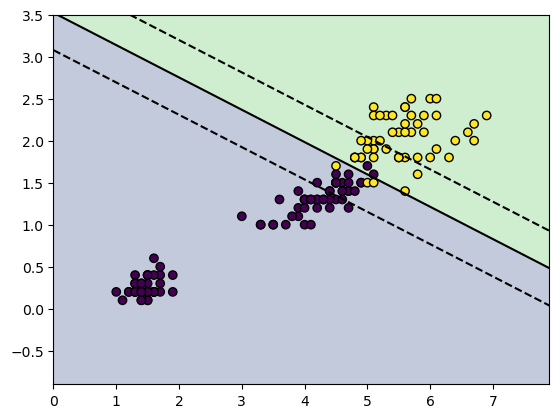

In [31]:
# 범위 설정
x0_min, x0_max =  x[:,0].min()-1, x[:,0].max()+1
x1_min, x1_max =  x[:,1].min()-1, x[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(x0_min,x0_max,500),
    np.linspace(x1_min,x1_max,500)
)
grid = np.c_[xx.ravel(),yy.ravel()]

z = pipeline.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx,yy,z, alpha=0.3)  # 결정영역
plt.scatter(x[:,0], x[:,1], c=y, edgecolors='k')

# 결정 경계
decision = pipeline.decision_function(grid)
decision = decision.reshape(xx.shape)
plt.contour(xx, yy, decision, levels = [-1,0,1], linestyles = ['--', '-', '--'], 
            colors='k')

plt.show()

model --> lr --------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        50
           1       0.86      0.86      0.86        50

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100

model --> sgd --------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        50
           1       0.91      0.82      0.86        50

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



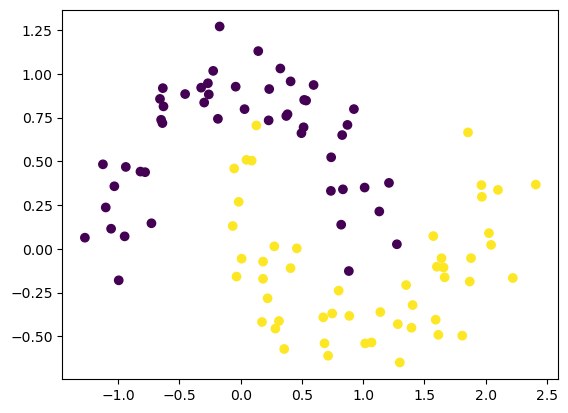

In [35]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pylab as plt
X,y = make_moons(n_samples=100, noise=0.15, random_state=42)
plt.scatter(X[:,0], X[:,1],c=y)

# 분류모델
from sklearn.linear_model import LogisticRegression

models = {'lr':LogisticRegression(random_state=42), 'sgd':SGDClassifier(random_state=42)}

for label,model in models.items():
    pipeline = Pipeline([
        ('scale', StandardScaler()),
        (label,model)
    ])
    pipeline.fit(X,y)
    predict = pipeline.predict(X)
    print(f'model --> {label}','-'*50)    
    print(classification_report(y,predict))

#파이프라인 만들어서 모델 학습, 예측값, f1-score

In [36]:
# svm 적용
from sklearn.svm import SVC
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    #('svc',SVC(kernel='poly',degree=3,C=5,coef0=1))
    ('svc',SVC(kernel='rbf'))
])
pipeline.fit(X,y)
predict = pipeline.predict(X)
print(classification_report(y,predict))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.96      0.92      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [ ]:
# svm 적용

from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('svc',SVC(kernel='poly', degree=3, C=5,coef0=1))
    ('svc',SVC(kernel='rbf'))
])

pipeline.fit(x,y)
predict = pipeline.predict(x)
print(classification_report(y,predict))

In [34]:
# 와인 품질 분류
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

wine = load_wine(as_frame=True)
x = wine.data.to_numpy()
y = wine.target
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10, gamma=0.1))
])
pipeline.fit(x_train, y_train)
predict = pipeline.predict(x_test)
print(classification_report(y_test, predict))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

